# Оценка моделей на MMBench-ru

В этом ноутбуке сравниваются локальные визуально-языковые модели на датасете `deepvk/MMBench-ru`. Обучение не запускается: модели только загружаются для инференса, предсказания сохраняются в CSV, а метрики считаются на одной и той же подвыборке.

## Как запускать

Ожидаемые локальные пути:

- `data/MMBench-ru/mmbench_ru_dev.parquet` — dev split MMBench-ru;
- `models/Qwen2.5-VL-3B-Instruct` — базовая Qwen2.5-VL;
- `models/SmolVLM-Instruct` — базовая SmolVLM;
- `outputs/qwen_lora_adapter`, `outputs/qwen_lora_adapter_2`, `outputs/smolvlm_lora_adapter` — LoRA-адаптеры, если они есть.

Датасет не скачивается заново. Изображения не загружаются в память заранее: они читаются из parquet батчами во время инференса.

## 1. Импорты и общие функции

Импорты для моделей сделаны мягкими: если Qwen, PEFT или `qwen-vl-utils` недоступны, соответствующая модель будет пропущена, а остальные оценки продолжатся.

In [1]:
from pathlib import Path
from io import BytesIO
import gc
import json
import math
import platform
import re
import sys
import time
import warnings

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from PIL import Image, UnidentifiedImageError
from tqdm.auto import tqdm

import matplotlib.pyplot as plt

try:
    import datasets
    DATASETS_AVAILABLE = True
except ImportError:
    datasets = None
    DATASETS_AVAILABLE = False

try:
    import torch
    TORCH_AVAILABLE = True
except ImportError:
    torch = None
    TORCH_AVAILABLE = False

try:
    import transformers
    from transformers import AutoProcessor
    try:
        from transformers import set_seed
    except ImportError:
        set_seed = None
    TRANSFORMERS_AVAILABLE = True
except ImportError:
    transformers = None
    AutoProcessor = None
    set_seed = None
    TRANSFORMERS_AVAILABLE = False

try:
    from transformers import Qwen2_5_VLForConditionalGeneration
except Exception:
    Qwen2_5_VLForConditionalGeneration = None

try:
    from qwen_vl_utils import process_vision_info
except Exception:
    process_vision_info = None

try:
    from peft import PeftModel
    PEFT_AVAILABLE = True
except ImportError:
    PeftModel = None
    PEFT_AVAILABLE = False

SmolVLMModelClass = None
if TRANSFORMERS_AVAILABLE:
    for class_name in [
        "AutoModelForImageTextToText",
        "AutoModelForVision2Seq",
        "Idefics3ForConditionalGeneration",
    ]:
        try:
            SmolVLMModelClass = getattr(transformers, class_name)
            break
        except AttributeError:
            continue

from IPython.display import display, Markdown

pd.set_option("display.max_colwidth", 160)
warnings.filterwarnings("once")

NOTEBOOK_WARNINGS = []
MODEL_LOAD_WARNINGS = []
GENERATION_WARNINGS = []
IMAGE_WARNINGS = []


def show_df(df, max_rows=20, index=False):
    """Компактный вывод таблиц в ноутбуке."""
    table = df.head(max_rows).copy() if max_rows is not None else df.copy()
    if not index:
        table = table.reset_index(drop=True)
    display(table)


def show_markdown(text):
    display(Markdown(str(text).strip()))


def add_warning(message, bucket=NOTEBOOK_WARNINGS):
    bucket.append(str(message))


def show_message_list(title, messages, max_items=10):
    if not messages:
        return
    visible = list(messages[:max_items])
    lines = [f"**{title}**", ""]
    lines.extend(f"- {message}" for message in visible)
    if len(messages) > max_items:
        lines.append(f"- ... еще {len(messages) - max_items} сообщений сохранено в списке предупреждений.")
    show_markdown("\n".join(lines))

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Пути и параметры оценки

Все пути строятся относительно корня репозитория. Основная подвыборка ограничена `MAX_EVAL_SAMPLES = 500`, чтобы первый запуск был быстрым.

In [2]:
def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Не удалось найти корень проекта относительно текущей директории.")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "MMBench-ru"
MMBENCH_PARQUET_PATH = DATA_DIR / "mmbench_ru_dev.parquet"

QWEN_MODEL_DIR = PROJECT_ROOT / "models" / "Qwen2.5-VL-3B-Instruct"
SMOLVLM_MODEL_DIR = PROJECT_ROOT / "models" / "SmolVLM-Instruct"

LORA_ADAPTER_DIRS = {
    "Qwen2.5-VL + LoRA #1": PROJECT_ROOT / "outputs" / "qwen_lora_adapter",
    "Qwen2.5-VL + LoRA #2": PROJECT_ROOT / "outputs" / "qwen_lora_adapter_2",
    "SmolVLM + LoRA": PROJECT_ROOT / "outputs" / "smolvlm_lora_adapter",
}

REPORT_DIR = PROJECT_ROOT / "reports" / "evaluation"
PREDICTIONS_PATH = REPORT_DIR / "mmbench_ru_predictions.csv"
METRICS_PATH = REPORT_DIR / "mmbench_ru_metrics.csv"

MAX_EVAL_SAMPLES = 500
MAX_NEW_TOKENS = 8
MAX_PIXELS = 640 * 28 * 28
SEED = 42
PARQUET_IMAGE_BATCH_SIZE = 32

MIN_PIXELS = 256 * 28 * 28
SMOLVLM_LONGEST_EDGE = int(math.sqrt(MAX_PIXELS))

REPORT_DIR.mkdir(parents=True, exist_ok=True)

if TRANSFORMERS_AVAILABLE and set_seed is not None:
    set_seed(SEED)
if TORCH_AVAILABLE:
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

if not TORCH_AVAILABLE:
    add_warning("PyTorch не установлен: инференс моделей будет пропущен.")
elif not torch.cuda.is_available():
    add_warning("CUDA недоступна: инференс на CPU может быть очень медленным.")

config_df = pd.DataFrame([
    {"Параметр": "project_root", "Значение": str(PROJECT_ROOT)},
    {"Параметр": "mmbench_parquet", "Значение": str(MMBENCH_PARQUET_PATH)},
    {"Параметр": "qwen_model_dir", "Значение": str(QWEN_MODEL_DIR)},
    {"Параметр": "smolvlm_model_dir", "Значение": str(SMOLVLM_MODEL_DIR)},
    {"Параметр": "predictions_path", "Значение": str(PREDICTIONS_PATH)},
    {"Параметр": "metrics_path", "Значение": str(METRICS_PATH)},
    {"Параметр": "max_eval_samples", "Значение": MAX_EVAL_SAMPLES},
    {"Параметр": "max_new_tokens", "Значение": MAX_NEW_TOKENS},
    {"Параметр": "max_pixels", "Значение": MAX_PIXELS},
    {"Параметр": "seed", "Значение": SEED},
])
show_df(config_df, max_rows=None)
show_message_list("Замечания по окружению", NOTEBOOK_WARNINGS)

,Параметр,Значение
0,project_root,c:\Users\user\Desktop\Практика\vk-vision-language-vqa
1,mmbench_parquet,c:\Users\user\Desktop\Практика\vk-vision-language-vqa\data\MMBench-ru\mmbench_ru_dev.parquet
2,qwen_model_dir,c:\Users\user\Desktop\Практика\vk-vision-language-vqa\models\Qwen2.5-VL-3B-Instruct
3,smolvlm_model_dir,c:\Users\user\Desktop\Практика\vk-vision-language-vqa\models\SmolVLM-Instruct
4,predictions_path,c:\Users\user\Desktop\Практика\vk-vision-language-vqa\reports\evaluation\mmbench_ru_predictions.csv
5,metrics_path,c:\Users\user\Desktop\Практика\vk-vision-language-vqa\reports\evaluation\mmbench_ru_metrics.csv
6,max_eval_samples,500
7,max_new_tokens,8
8,max_pixels,501760
9,seed,42


## 3. Проверка окружения

Модели всегда загружаются с `eager` attention.

In [ ]:
def select_inference_dtype():
    if not TORCH_AVAILABLE:
        return None
    if torch.cuda.is_available() and torch.cuda.is_bf16_supported():
        return torch.bfloat16
    if torch.cuda.is_available():
        return torch.float16
    return torch.float32


MODEL_DTYPE = select_inference_dtype()
DEFAULT_ATTN_IMPLEMENTATION = "eager"

try:
    gpu_name = torch.cuda.get_device_name(0) if TORCH_AVAILABLE and torch.cuda.is_available() else None
except Exception:
    gpu_name = None

env_df = pd.DataFrame([
    {"Параметр": "python", "Значение": sys.version.split()[0]},
    {"Параметр": "platform", "Значение": platform.platform()},
    {"Параметр": "datasets", "Значение": datasets.__version__ if DATASETS_AVAILABLE else "не установлен"},
    {"Параметр": "torch", "Значение": torch.__version__ if TORCH_AVAILABLE else "не установлен"},
    {"Параметр": "transformers", "Значение": transformers.__version__ if TRANSFORMERS_AVAILABLE else "не установлен"},
    {"Параметр": "peft", "Значение": "доступен" if PEFT_AVAILABLE else "не установлен"},
    {"Параметр": "cuda_available", "Значение": torch.cuda.is_available() if TORCH_AVAILABLE else False},
    {"Параметр": "gpu", "Значение": gpu_name},
    {"Параметр": "inference_dtype", "Значение": str(MODEL_DTYPE)},
    {"Параметр": "attention", "Значение": DEFAULT_ATTN_IMPLEMENTATION},
])
show_df(env_df, max_rows=None)

Параметр                   Значение
0              python                     3.11.0
1            platform  Windows-10-10.0.26200-SP0
2            datasets                      5.0.0
3               torch                2.5.1+cu121
4        transformers                5.14.0.dev0
5                peft                   доступен
6      cuda_available                       True
7                 gpu    NVIDIA GeForce RTX 3080
8     inference_dtype             torch.bfloat16
10          attention                      eager

**Замечания по загрузке моделей**

- attention = eager.


## 4. Структура локального MMBench-ru

Автоматически ищем parquet-файлы внутри `data/MMBench-ru`, затем явно выбираем `mmbench_ru_dev.parquet`. Для просмотра структуры байты изображений не читаются.

In [4]:
def discover_parquet_files(data_dir):
    rows = []
    data_dir = Path(data_dir)
    for path in sorted(data_dir.rglob("*.parquet")):
        if ".cache" in path.parts:
            continue
        parquet_file = pq.ParquetFile(path)
        schema_names = parquet_file.schema_arrow.names
        split_values = []
        if "split" in schema_names:
            split_table = parquet_file.read(columns=["split"])
            split_values = sorted({str(value) for value in split_table.column("split").to_pylist() if value is not None})
        rows.append({
            "split": ", ".join(split_values) if split_values else "не указан",
            "rows": parquet_file.metadata.num_rows,
            "columns": schema_names,
            "file": path.name,
            "path": path,
            "selected": path.resolve() == MMBENCH_PARQUET_PATH.resolve(),
        })
    return pd.DataFrame(rows)


parquet_files_df = discover_parquet_files(DATA_DIR)
if parquet_files_df.empty:
    raise FileNotFoundError(f"В папке {DATA_DIR} не найдены parquet-файлы.")
if not MMBENCH_PARQUET_PATH.exists():
    raise FileNotFoundError(f"Ожидался локальный файл MMBench-ru: {MMBENCH_PARQUET_PATH}")

structure_view_df = parquet_files_df.copy()
structure_view_df["columns"] = structure_view_df["columns"].apply(lambda cols: ", ".join(cols))
structure_view_df["path"] = structure_view_df["path"].apply(lambda path: str(path.relative_to(PROJECT_ROOT)))
show_df(structure_view_df, max_rows=None)

mmbench_file = pq.ParquetFile(MMBENCH_PARQUET_PATH)
MMBENCH_COLUMNS = mmbench_file.schema_arrow.names
NON_IMAGE_COLUMNS = [column for column in MMBENCH_COLUMNS if column != "image"]

first_row = mmbench_file.read_row_group(0, columns=NON_IMAGE_COLUMNS).slice(0, 1).to_pydict()
first_row = {key: values[0] if values else None for key, values in first_row.items()}
if "image" in MMBENCH_COLUMNS:
    first_row["image"] = "<байты изображения скрыты>"

print("Колонки выбранного файла:", MMBENCH_COLUMNS)
show_df(pd.DataFrame([first_row]), max_rows=1)

,split,rows,columns,file,path,selected
0,dev,3910,"index, question, hint, A, B, C, D, answer, category, image, source, l2-category, comment, split",mmbench_ru_dev.parquet,data\MMBench-ru\mmbench_ru_dev.parquet,True


Колонки выбранного файла: ['index', 'question', 'hint', 'A', 'B', 'C', 'D', 'answer', 'category', 'image', 'source', 'l2-category', 'comment', 'split']


,index,question,hint,A,B,C,D,answer,category,source,l2-category,comment,split,image
0,267,Какая часть яблони может вырасти в новое дерево?,На этой диаграмме показан жизненный цикл яблони.,семя,лист,nan,nan,A,physical_property_reasoning,scienceqa,attribute_reasoning,nan,dev,<байты изображения скрыты>


## 5. Проверка полей датасета

Проверяем наличие `image`, `question`, `answer`, `options`, `hint`, `category` и близких аналогов.

In [5]:
def find_column_name(columns, candidates):
    lower_to_original = {str(column).lower(): column for column in columns}
    for candidate in candidates:
        if candidate.lower() in lower_to_original:
            return lower_to_original[candidate.lower()]
    return None


FIELD_CANDIDATES = {
    "image": ["image", "img", "picture", "image_path"],
    "question": ["question", "query", "prompt", "text"],
    "answer": ["answer", "ground_truth", "gt_answer", "label"],
    "hint": ["hint", "context", "caption", "description"],
    "category": ["category", "l2-category", "subject", "type"],
    "split": ["split", "subset"],
}

field_rows = []
for logical_name, candidates in FIELD_CANDIDATES.items():
    found = find_column_name(MMBENCH_COLUMNS, candidates)
    field_rows.append({
        "Поле": logical_name,
        "Найденная колонка": found if found is not None else "не найдено",
        "Кандидаты": ", ".join(candidates),
    })

option_columns = [label for label in ["A", "B", "C", "D"] if label in MMBENCH_COLUMNS]
field_rows.append({
    "Поле": "options",
    "Найденная колонка": ", ".join(option_columns) if option_columns else "не найдено",
    "Кандидаты": "A, B, C, D, options",
})

field_map_df = pd.DataFrame(field_rows)
show_df(field_map_df, max_rows=None)

QUESTION_COLUMN = find_column_name(MMBENCH_COLUMNS, FIELD_CANDIDATES["question"])
ANSWER_COLUMN = find_column_name(MMBENCH_COLUMNS, FIELD_CANDIDATES["answer"])
HINT_COLUMN = find_column_name(MMBENCH_COLUMNS, FIELD_CANDIDATES["hint"])
CATEGORY_COLUMN = find_column_name(MMBENCH_COLUMNS, FIELD_CANDIDATES["category"])
SPLIT_COLUMN = find_column_name(MMBENCH_COLUMNS, FIELD_CANDIDATES["split"])

if QUESTION_COLUMN is None or ANSWER_COLUMN is None:
    raise ValueError(f"Не найдены обязательные поля question/answer. Доступные колонки: {MMBENCH_COLUMNS}")
if "image" not in MMBENCH_COLUMNS:
    raise ValueError(f"Не найдена колонка image. Доступные колонки: {MMBENCH_COLUMNS}")

,Поле,Найденная колонка,Кандидаты
0,image,image,"image, img, picture, image_path"
1,question,question,"question, query, prompt, text"
2,answer,answer,"answer, ground_truth, gt_answer, label"
3,hint,hint,"hint, context, caption, description"
4,category,category,"category, l2-category, subject, type"
5,split,split,"split, subset"
6,options,"A, B, C, D","A, B, C, D, options"


## 6. Загрузка метаданных и выбор подвыборки

В память загружаются только текстовые поля. Колонка `image` остается в parquet и читается позже батчами.

In [6]:
def short_cell(value, max_len=120):
    if isinstance(value, dict):
        return {key: short_cell(item, max_len=max_len) for key, item in value.items()}
    if isinstance(value, (bytes, bytearray)):
        return f"<bytes: {len(value)} bytes>"
    if value is None:
        return None
    text = str(value)
    if len(text) > max_len:
        return text[:max_len] + "..."
    return value


metadata_df = mmbench_file.read(columns=NON_IMAGE_COLUMNS).to_pandas()
metadata_df["parquet_row_id"] = np.arange(len(metadata_df))

available_examples = len(metadata_df)
sample_n = min(MAX_EVAL_SAMPLES, available_examples)
eval_sample_raw = metadata_df.sample(n=sample_n, random_state=SEED).reset_index(drop=True)
eval_sample_raw["row_id"] = np.arange(len(eval_sample_raw))
eval_sample = eval_sample_raw.sort_values("parquet_row_id").reset_index(drop=True)

load_summary_df = pd.DataFrame([
    {"Параметр": "selected_file", "Значение": str(MMBENCH_PARQUET_PATH.relative_to(PROJECT_ROOT))},
    {"Параметр": "available_examples", "Значение": available_examples},
    {"Параметр": "sample_examples", "Значение": len(eval_sample)},
    {"Параметр": "split_values", "Значение": ", ".join(sorted(metadata_df[SPLIT_COLUMN].astype(str).unique())) if SPLIT_COLUMN else "не указан"},
    {"Параметр": "image_loading", "Значение": "батчами из parquet во время инференса"},
])
show_df(load_summary_df, max_rows=None)

preview_columns = [
    column for column in
    ["row_id", "parquet_row_id", SPLIT_COLUMN, QUESTION_COLUMN, HINT_COLUMN, "A", "B", "C", "D", ANSWER_COLUMN, CATEGORY_COLUMN]
    if column is not None and column in eval_sample.columns
]
preview_df = eval_sample[preview_columns].head(5).copy()
preview_df = preview_df.map(short_cell) if hasattr(preview_df, "map") else preview_df.applymap(short_cell)
show_df(preview_df, max_rows=5)

,Параметр,Значение
0,selected_file,data\MMBench-ru\mmbench_ru_dev.parquet
1,available_examples,3910
2,sample_examples,500
3,split_values,dev
4,image_loading,батчами из parquet во время инференса


,row_id,parquet_row_id,split,question,hint,A,B,C,D,answer,category
0,110,8,dev,Какая картина более яркая?,nan,Первая картина,Вторая картина,nan,nan,A,image_quality
1,321,12,dev,Какая картинка более яркая?,nan,Первая картинка,Вторая картинка,nan,nan,A,image_quality
2,17,14,dev,Какая из изображений более яркое?,nan,Первое изображение,Второе изображение,nan,nan,A,image_quality
3,179,17,dev,Какое изображение более яркое?,nan,Первое изображение,Второе изображение,nan,nan,B,image_quality
4,237,26,dev,Это место переполнено?,nan,да,нет,nan,nan,B,image_scene


## 7. Подготовка одного примера

`prepare_example(row)` приводит строку к единому формату. Если есть варианты `A/B/C/D`, промпт просит модель выбрать только одну букву. Если вариантов нет, используется короткий VQA-промпт и exact match после нормализации.

In [7]:
OPTION_LABELS = ["A", "B", "C", "D"]
CYRILLIC_OPTION_MAP = str.maketrans({"А": "A", "В": "B", "С": "C", "Д": "D", "а": "A", "в": "B", "с": "C", "д": "D"})


def is_missing_text(value):
    if value is None:
        return True
    if isinstance(value, float) and pd.isna(value):
        return True
    text = str(value).strip()
    return text == "" or text.lower() in {"nan", "none", "null", "<na>"}


def normalize_answer(text):
    if text is None or (isinstance(text, float) and pd.isna(text)):
        return ""
    text = str(text).lower().strip().replace("ё", "е")
    text = re.sub(r"[^\w\s]", " ", text, flags=re.UNICODE)
    text = re.sub(r"\s+", " ", text).strip()
    yes_no_aliases = {
        "yes": "yes", "y": "yes", "yeah": "yes", "yep": "yes", "true": "yes",
        "да": "yes", "ага": "yes", "верно": "yes",
        "no": "no", "n": "no", "nope": "no", "false": "no",
        "нет": "no", "неа": "no",
    }
    if text in yes_no_aliases:
        return yes_no_aliases[text]
    first_token = text.split()[0] if text else ""
    if first_token in yes_no_aliases:
        return yes_no_aliases[first_token]
    return text


def get_options(row):
    options = {}
    for label in OPTION_LABELS:
        if label in row.index and not is_missing_text(row[label]):
            options[label] = str(row[label]).strip()
    return options


def options_to_text(options):
    return "\n".join(f"{label}. {text}" for label, text in options.items())


def normalize_choice_answer(answer, options):
    if is_missing_text(answer):
        return ""
    text = str(answer).strip().translate(CYRILLIC_OPTION_MAP).upper()
    if text in options:
        return text
    match = re.search(r"(?<![A-Z])([ABCD])(?![A-Z])", text)
    if match and match.group(1) in options:
        return match.group(1)
    answer_norm = normalize_answer(answer)
    for label, option_text in options.items():
        if answer_norm == normalize_answer(option_text):
            return label
    return text


def extract_choice_letter(prediction, options):
    if is_missing_text(prediction):
        return ""
    text = str(prediction).strip().translate(CYRILLIC_OPTION_MAP)
    text = re.sub(r"^\s*(assistant|ответ)\s*[:\-]\s*", "", text, flags=re.IGNORECASE)
    text_upper = text.upper()
    if text_upper[:1] in options:
        return text_upper[:1]
    match = re.search(r"(?<![A-Z])([ABCD])(?![A-Z])", text_upper)
    if match and match.group(1) in options:
        return match.group(1)
    prediction_norm = normalize_answer(text)
    for label, option_text in options.items():
        if prediction_norm == normalize_answer(option_text):
            return label
    return ""


def build_multiple_choice_prompt(question, options, hint=None):
    parts = [
        "Ответь на вопрос по изображению.",
        "Выбери один правильный вариант из A, B, C или D.",
    ]
    if not is_missing_text(hint):
        parts.append(f"Подсказка: {str(hint).strip()}")
    parts.extend([
        f"Вопрос: {str(question).strip()}",
        "Варианты ответа:",
        options_to_text(options),
        "Ответь только одной буквой: A, B, C или D.",
    ])
    return "\n".join(parts)


def build_open_ended_prompt(question, hint=None):
    parts = ["Ответь на вопрос по изображению коротко: одним словом или короткой фразой."]
    if not is_missing_text(hint):
        parts.append(f"Подсказка: {str(hint).strip()}")
    parts.append(f"Вопрос: {str(question).strip()}")
    parts.append("Ответ:")
    return "\n".join(parts)


def prepare_example(row):
    options = get_options(row)
    question = str(row[QUESTION_COLUMN]).strip()
    hint = row[HINT_COLUMN] if HINT_COLUMN is not None and HINT_COLUMN in row.index else None
    answer = row[ANSWER_COLUMN]
    task_type = "multiple_choice" if len(options) >= 2 else "open_ended"
    if task_type == "multiple_choice":
        true_answer_norm = normalize_choice_answer(answer, options)
        prompt = build_multiple_choice_prompt(question, options, hint=hint)
        metric_name = "accuracy"
    else:
        true_answer_norm = normalize_answer(answer)
        prompt = build_open_ended_prompt(question, hint=hint)
        metric_name = "exact_match"
    return {
        "row_id": int(row["row_id"]),
        "parquet_row_id": int(row["parquet_row_id"]),
        "split": str(row[SPLIT_COLUMN]) if SPLIT_COLUMN is not None and SPLIT_COLUMN in row.index else "",
        "question": question,
        "hint": "" if is_missing_text(hint) else str(hint).strip(),
        "options": options,
        "options_text": options_to_text(options) if options else "",
        "true_answer": str(answer).strip(),
        "true_answer_norm": true_answer_norm,
        "category": str(row[CATEGORY_COLUMN]) if CATEGORY_COLUMN is not None and CATEGORY_COLUMN in row.index else "",
        "task_type": task_type,
        "metric_name": metric_name,
        "prompt": prompt,
    }


def score_prediction(prediction, example):
    if example["task_type"] == "multiple_choice":
        prediction_norm = extract_choice_letter(prediction, example["options"])
        is_correct = prediction_norm == example["true_answer_norm"]
    else:
        prediction_norm = normalize_answer(prediction)
        is_correct = prediction_norm == example["true_answer_norm"]
    return prediction_norm, bool(is_correct)


prepared_preview = [prepare_example(row) for _, row in eval_sample.head(3).iterrows()]
prepared_preview_df = pd.DataFrame([
    {
        "row_id": item["row_id"],
        "task_type": item["task_type"],
        "question": item["question"],
        "options": item["options_text"],
        "true_answer": item["true_answer"],
        "true_answer_norm": item["true_answer_norm"],
        "prompt": item["prompt"],
    }
    for item in prepared_preview
])
show_df(prepared_preview_df, max_rows=3)

,row_id,task_type,question,options,true_answer,true_answer_norm,prompt
0,110,multiple_choice,Какая картина более яркая?,A. Первая картина\nB. Вторая картина,A,A,"Ответь на вопрос по изображению.\nВыбери один правильный вариант из A, B, C или D.\nВопрос: Какая картина более яркая?\nВарианты ответа:\nA. Первая картина\..."
1,321,multiple_choice,Какая картинка более яркая?,A. Первая картинка\nB. Вторая картинка,A,A,"Ответь на вопрос по изображению.\nВыбери один правильный вариант из A, B, C или D.\nВопрос: Какая картинка более яркая?\nВарианты ответа:\nA. Первая картинк..."
2,17,multiple_choice,Какая из изображений более яркое?,A. Первое изображение\nB. Второе изображение,A,A,"Ответь на вопрос по изображению.\nВыбери один правильный вариант из A, B, C или D.\nВопрос: Какая из изображений более яркое?\nВарианты ответа:\nA. Первое и..."


## 8. Потоковое чтение изображений из parquet

Генератор проходит по колонке `image` батчами и отдает только строки из выбранной подвыборки.

In [8]:
def iter_selected_image_records(parquet_path, selected_parquet_row_ids, batch_size=PARQUET_IMAGE_BATCH_SIZE):
    selected = {int(row_id) for row_id in selected_parquet_row_ids}
    if not selected:
        return
    parquet_file = pq.ParquetFile(parquet_path)
    offset = 0
    for batch in parquet_file.iter_batches(batch_size=batch_size, columns=["image"]):
        records = batch.to_pylist()
        for batch_index, record in enumerate(records):
            parquet_row_id = offset + batch_index
            if parquet_row_id in selected:
                yield parquet_row_id, record.get("image")
        offset += batch.num_rows


def resolve_image_path(image_path, search_roots=None):
    search_roots = search_roots or [DATA_DIR, PROJECT_ROOT]
    image_path = Path(image_path)
    if image_path.is_absolute():
        return image_path
    for root in search_roots:
        candidate = Path(root) / image_path
        if candidate.exists():
            return candidate
    return image_path


def load_image_safely(image_value, warn=True):
    try:
        if isinstance(image_value, Image.Image):
            return image_value.convert("RGB")
        if isinstance(image_value, dict):
            if image_value.get("bytes") is not None:
                return Image.open(BytesIO(image_value["bytes"])).convert("RGB")
            if image_value.get("path"):
                image_path = resolve_image_path(image_value["path"])
                if not image_path.exists():
                    raise FileNotFoundError(f"Изображение не найдено: {image_path}")
                return Image.open(image_path).convert("RGB")
        if isinstance(image_value, (bytes, bytearray)):
            return Image.open(BytesIO(image_value)).convert("RGB")
        if isinstance(image_value, (str, Path)):
            image_path = resolve_image_path(image_value)
            if not image_path.exists():
                raise FileNotFoundError(f"Изображение не найдено: {image_path}")
            return Image.open(image_path).convert("RGB")
        raise TypeError(f"Неподдерживаемый тип изображения: {type(image_value)}")
    except (FileNotFoundError, OSError, UnidentifiedImageError, TypeError, ValueError) as error:
        if warn:
            add_warning(f"Пропускаем изображение: {error}", IMAGE_WARNINGS)
        return None


first_selected_id = int(eval_sample.iloc[0]["parquet_row_id"])
first_image_record = next(iter_selected_image_records(MMBENCH_PARQUET_PATH, [first_selected_id]), None)
if first_image_record is None:
    raise ValueError("Не удалось прочитать первое изображение из parquet.")

_, first_image_value = first_image_record
first_image = load_image_safely(first_image_value)
if first_image is None:
    raise ValueError("Первое изображение из подвыборки не удалось открыть через PIL.")

image_check_df = pd.DataFrame([{
    "parquet_row_id": first_selected_id,
    "image_size": first_image.size,
    "image_mode": first_image.mode,
}])
first_image.close()
show_df(image_check_df)
show_message_list("Замечания по изображениям", IMAGE_WARNINGS)

,parquet_row_id,image_size,image_mode
0,8,"(512, 192)",RGB


## 9. Список моделей для сравнения

Базовые модели берутся только из локальных папок `models/`. LoRA-адаптеры добавляются в список, если соответствующая папка существует и установлен `peft`.

In [9]:
def read_adapter_base_model(adapter_dir):
    config_path = Path(adapter_dir) / "adapter_config.json"
    if not config_path.exists():
        return ""
    try:
        with config_path.open("r", encoding="utf-8") as file:
            config = json.load(file)
        return str(config.get("base_model_name_or_path", ""))
    except Exception:
        return ""


def infer_adapter_family(adapter_dir):
    adapter_dir = Path(adapter_dir)
    text = f"{adapter_dir.name} {read_adapter_base_model(adapter_dir)}".lower()
    if "qwen" in text:
        return "qwen"
    if "smol" in text or "idefics" in text:
        return "smolvlm"
    return "unknown"


def make_model_specs():
    specs = [
        {
            "name": "Qwen2.5-VL базовая",
            "family": "qwen",
            "model_dir": QWEN_MODEL_DIR,
            "adapter_dir": None,
            "enabled": QWEN_MODEL_DIR.exists(),
            "skip_reason": "" if QWEN_MODEL_DIR.exists() else "папка модели не найдена",
        },
        {
            "name": "SmolVLM базовая",
            "family": "smolvlm",
            "model_dir": SMOLVLM_MODEL_DIR,
            "adapter_dir": None,
            "enabled": SMOLVLM_MODEL_DIR.exists(),
            "skip_reason": "" if SMOLVLM_MODEL_DIR.exists() else "папка модели не найдена",
        },
    ]
    for name, adapter_dir in LORA_ADAPTER_DIRS.items():
        family = infer_adapter_family(adapter_dir)
        model_dir = QWEN_MODEL_DIR if family == "qwen" else SMOLVLM_MODEL_DIR if family == "smolvlm" else None
        reasons = []
        if not adapter_dir.exists():
            reasons.append("LoRA-адаптер не найден")
        if model_dir is None:
            reasons.append("не удалось определить семейство модели")
        elif not model_dir.exists():
            reasons.append("базовая модель не найдена")
        if not PEFT_AVAILABLE:
            reasons.append("peft не установлен")
        specs.append({
            "name": name,
            "family": family,
            "model_dir": model_dir,
            "adapter_dir": adapter_dir,
            "enabled": adapter_dir.exists() and model_dir is not None and model_dir.exists() and PEFT_AVAILABLE,
            "skip_reason": "; ".join(reasons),
        })
    return specs


MODEL_SPECS = make_model_specs()
model_specs_df = pd.DataFrame([
    {
        "Модель": spec["name"],
        "Семейство": spec["family"],
        "Базовая папка": str(spec["model_dir"].relative_to(PROJECT_ROOT)) if spec["model_dir"] and spec["model_dir"].exists() else str(spec["model_dir"]),
        "LoRA": str(spec["adapter_dir"].relative_to(PROJECT_ROOT)) if spec["adapter_dir"] and spec["adapter_dir"].exists() else "",
        "Будет оцениваться": spec["enabled"],
        "Причина пропуска": spec["skip_reason"],
    }
    for spec in MODEL_SPECS
])
show_df(model_specs_df, max_rows=None)

,Модель,Семейство,Базовая папка,LoRA,Будет оцениваться,Причина пропуска
0,Qwen2.5-VL базовая,qwen,models\Qwen2.5-VL-3B-Instruct,,True,
1,SmolVLM базовая,smolvlm,models\SmolVLM-Instruct,,True,
2,Qwen2.5-VL + LoRA #1,qwen,models\Qwen2.5-VL-3B-Instruct,outputs\qwen_lora_adapter,True,
3,Qwen2.5-VL + LoRA #2,qwen,models\Qwen2.5-VL-3B-Instruct,outputs\qwen_lora_adapter_2,True,
4,SmolVLM + LoRA,smolvlm,models\SmolVLM-Instruct,outputs\smolvlm_lora_adapter,True,


## 10. Единый интерфейс моделей

Основные функции: `load_model(...)`, `predict_one(...)`, `evaluate_model(...)`.

In [10]:
def get_model_input_device(model):
    if not TORCH_AVAILABLE:
        return None
    try:
        for parameter in model.parameters():
            if parameter.device.type != "meta":
                return parameter.device
    except Exception:
        pass
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def release_memory():
    gc.collect()
    if TORCH_AVAILABLE and torch.cuda.is_available():
        torch.cuda.empty_cache()


def load_processor_for_spec(spec):
    if not TRANSFORMERS_AVAILABLE:
        raise ImportError("transformers не установлен")
    model_dir = str(spec["model_dir"])
    if spec["family"] == "qwen":
        processor_kwargs = {"local_files_only": True, "min_pixels": MIN_PIXELS, "max_pixels": MAX_PIXELS}
    else:
        processor_kwargs = {"local_files_only": True, "size": {"longest_edge": SMOLVLM_LONGEST_EDGE}}
    try:
        processor = AutoProcessor.from_pretrained(model_dir, **processor_kwargs)
    except TypeError:
        processor_kwargs.pop("min_pixels", None)
        processor_kwargs.pop("max_pixels", None)
        processor_kwargs.pop("size", None)
        processor = AutoProcessor.from_pretrained(model_dir, **processor_kwargs)
    if getattr(processor, "tokenizer", None) is not None:
        if processor.tokenizer.pad_token is None:
            processor.tokenizer.pad_token = processor.tokenizer.eos_token
        processor.tokenizer.padding_side = "left"
    return processor


def from_pretrained_with_dtype(model_class, source, model_dtype, **kwargs):
    try:
        return model_class.from_pretrained(source, dtype=model_dtype, **kwargs)
    except TypeError:
        return model_class.from_pretrained(source, torch_dtype=model_dtype, **kwargs)


def load_qwen_base_model(spec):
    if Qwen2_5_VLForConditionalGeneration is None:
        raise ImportError("В transformers нет Qwen2_5_VLForConditionalGeneration")
    if process_vision_info is None:
        raise ImportError("Не установлен qwen-vl-utils")
    if not TORCH_AVAILABLE:
        raise ImportError("torch не установлен")
    source = str(spec["model_dir"])
    base_kwargs = {"local_files_only": True}
    if torch.cuda.is_available():
        base_kwargs["device_map"] = "auto"
    candidates = ["eager"]
    last_error = None
    for attn_impl in candidates:
        model_kwargs = dict(base_kwargs)
        model_kwargs["_attn_implementation"] = attn_impl
        try:
            model = from_pretrained_with_dtype(
                Qwen2_5_VLForConditionalGeneration,
                source,
                MODEL_DTYPE if torch.cuda.is_available() else torch.float32,
                **model_kwargs,
            )
            model.eval()
            return model, attn_impl
        except Exception as error:
            last_error = error
            break
    if not torch.cuda.is_available():
        model = from_pretrained_with_dtype(
            Qwen2_5_VLForConditionalGeneration,
            source,
            torch.float32,
            local_files_only=True,
            _attn_implementation="eager",
        )
        model.eval()
        return model, "eager"
    raise last_error


def load_smolvlm_base_model(spec):
    if SmolVLMModelClass is None:
        raise ImportError("В transformers нет подходящего класса для SmolVLM")
    if not TORCH_AVAILABLE:
        raise ImportError("torch не установлен")
    source = str(spec["model_dir"])
    candidates = ["eager"]
    last_error = None
    for attn_impl in candidates:
        try:
            model = from_pretrained_with_dtype(
                SmolVLMModelClass,
                source,
                MODEL_DTYPE if torch.cuda.is_available() else torch.float32,
                local_files_only=True,
                _attn_implementation=attn_impl,
            )
            model.to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))
            model.eval()
            return model, attn_impl
        except Exception as error:
            last_error = error
            break
    raise last_error


def load_model(spec):
    if not spec.get("enabled", False):
        add_warning(f"{spec['name']} пропущена: {spec.get('skip_reason', 'нет причины')}", MODEL_LOAD_WARNINGS)
        return None
    try:
        processor = load_processor_for_spec(spec)
        if spec["family"] == "qwen":
            model, attn_impl = load_qwen_base_model(spec)
        elif spec["family"] == "smolvlm":
            model, attn_impl = load_smolvlm_base_model(spec)
        else:
            raise ValueError(f"Неизвестное семейство модели: {spec['family']}")
        if spec.get("adapter_dir") is not None:
            if not PEFT_AVAILABLE:
                raise ImportError("peft не установлен")
            model = PeftModel.from_pretrained(model, str(spec["adapter_dir"]), local_files_only=True)
            model.eval()
        return {
            "name": spec["name"],
            "family": spec["family"],
            "processor": processor,
            "model": model,
            "attention": attn_impl,
        }
    except Exception as error:
        add_warning(f"{spec['name']} недоступна и будет пропущена: {error}", MODEL_LOAD_WARNINGS)
        return None


def generate_qwen_answer(bundle, image, prompt):
    processor = bundle["processor"]
    model = bundle["model"]
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": prompt},
        ],
    }]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(text=[text], images=image_inputs, videos=video_inputs, padding=True, return_tensors="pt")
    inputs = inputs.to(get_model_input_device(model))
    with torch.no_grad():
        generated_ids = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=False)
    generated_ids_trimmed = [
        output_ids[len(input_ids):]
        for input_ids, output_ids in zip(inputs.input_ids, generated_ids)
    ]
    return processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0].strip()


def generate_smolvlm_answer(bundle, image, prompt):
    processor = bundle["processor"]
    model = bundle["model"]
    messages = [{
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": prompt},
        ],
    }]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=text, images=[image], return_tensors="pt")
    inputs = inputs.to(get_model_input_device(model))
    with torch.no_grad():
        generated_ids = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=False)
    generated_ids_trimmed = generated_ids[:, inputs.input_ids.shape[1]:]
    output_text = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0]
    return re.sub(r"^\s*Assistant:\s*", "", output_text).strip()


def predict_one(model_bundle, example, image):
    if model_bundle["family"] == "qwen":
        return generate_qwen_answer(model_bundle, image, example["prompt"])
    if model_bundle["family"] == "smolvlm":
        return generate_smolvlm_answer(model_bundle, image, example["prompt"])
    raise ValueError(f"Неизвестное семейство модели: {model_bundle['family']}")

## 11. Запуск оценки

Каждая модель загружается отдельно, проходит по одной и той же подвыборке, после чего память очищается. Если модель недоступна, она будет пропущена.

In [ ]:
def build_metric_row(model_name, family, status, records_df, load_error=None, attention=None):
    if records_df is None or records_df.empty:
        return {
            "model_name": model_name,
            "family": family,
            "status": status,
            "main_metric": "accuracy / exact_match",
            "main_score": np.nan,
            "accuracy": np.nan,
            "exact_match": np.nan,
            "num_success": 0,
            "num_errors": 0,
            "num_correct": 0,
            "mean_inference_time_s": np.nan,
            "attention": attention,
            "load_error": load_error,
        }
    success_df = records_df[records_df["error"].isna()].copy()
    mc_df = success_df[success_df["task_type"] == "multiple_choice"]
    open_df = success_df[success_df["task_type"] == "open_ended"]
    accuracy = float(mc_df["is_correct"].mean()) if len(mc_df) else np.nan
    exact_match_score = float(open_df["is_correct"].mean()) if len(open_df) else np.nan
    main_score = float(success_df["is_correct"].mean()) if len(success_df) else np.nan
    if len(mc_df) and not len(open_df):
        main_metric = "accuracy"
    elif len(open_df) and not len(mc_df):
        main_metric = "exact_match"
    else:
        main_metric = "accuracy / exact_match"
    return {
        "model_name": model_name,
        "family": family,
        "status": status,
        "main_metric": main_metric,
        "main_score": main_score,
        "accuracy": accuracy,
        "exact_match": exact_match_score,
        "num_success": int(len(success_df)),
        "num_errors": int(records_df["error"].notna().sum()),
        "num_correct": int(success_df["is_correct"].sum()) if len(success_df) else 0,
        "mean_inference_time_s": float(success_df["inference_time_s"].mean()) if len(success_df) else np.nan,
        "attention": attention,
        "load_error": load_error,
    }


def evaluate_model(spec, dataframe):
    load_start = time.perf_counter()
    bundle = load_model(spec)
    load_time_s = time.perf_counter() - load_start
    if bundle is None:
        metrics = build_metric_row(
            model_name=spec["name"],
            family=spec["family"],
            status="skipped",
            records_df=pd.DataFrame(),
            load_error="см. MODEL_LOAD_WARNINGS",
        )
        metrics["load_time_s"] = load_time_s
        return pd.DataFrame(), metrics

    records = []
    row_map = {int(row["parquet_row_id"]): row for _, row in dataframe.iterrows()}
    selected_ids = sorted(row_map.keys())
    progress = tqdm(
        iter_selected_image_records(MMBENCH_PARQUET_PATH, selected_ids),
        total=len(selected_ids),
        desc=f"Инференс: {spec['name']}",
    )
    for parquet_row_id, image_value in progress:
        row = row_map[int(parquet_row_id)]
        example = prepare_example(row)
        image = None
        prediction = ""
        prediction_norm = ""
        is_correct = False
        error = None
        start = time.perf_counter()
        try:
            image = load_image_safely(image_value)
            if image is None:
                raise ValueError("изображение не удалось открыть")
            prediction = predict_one(bundle, example, image)
            prediction_norm, is_correct = score_prediction(prediction, example)
        except Exception as error_obj:
            error = str(error_obj)
            add_warning(f"{spec['name']} | row_id={example['row_id']}: {error}", GENERATION_WARNINGS)
            if TORCH_AVAILABLE and isinstance(error_obj, RuntimeError) and torch.cuda.is_available():
                torch.cuda.empty_cache()
        finally:
            inference_time_s = time.perf_counter() - start
            if image is not None:
                image.close()
        records.append({
            "model_name": spec["name"],
            "family": spec["family"],
            "row_id": example["row_id"],
            "parquet_row_id": example["parquet_row_id"],
            "split": example["split"],
            "category": example["category"],
            "task_type": example["task_type"],
            "metric_name": example["metric_name"],
            "question": example["question"],
            "hint": example["hint"],
            "options": example["options_text"],
            "true_answer": example["true_answer"],
            "true_answer_norm": example["true_answer_norm"],
            "prediction": prediction,
            "prediction_norm": prediction_norm,
            "is_correct": is_correct,
            "inference_time_s": inference_time_s,
            "error": error,
        })

    attention = bundle.get("attention")
    del bundle["model"]
    release_memory()

    records_df = pd.DataFrame(records)
    metrics = build_metric_row(
        model_name=spec["name"],
        family=spec["family"],
        status="ok",
        records_df=records_df,
        attention=attention,
    )
    metrics["load_time_s"] = load_time_s
    return records_df, metrics


all_prediction_parts = []
metric_rows = []

for spec in MODEL_SPECS:
    predictions_part, metrics_row = evaluate_model(spec, eval_sample)
    if not predictions_part.empty:
        all_prediction_parts.append(predictions_part)
    metric_rows.append(metrics_row)
    show_df(pd.DataFrame([metrics_row]))

predictions_df = pd.concat(all_prediction_parts, ignore_index=True) if all_prediction_parts else pd.DataFrame()
metrics_df = pd.DataFrame(metric_rows)
show_df(metrics_df, max_rows=None)

Инференс: Qwen2.5-VL базовая: 100%|██████████| 500/500 [02:08<00:00,  3.90it/s]


,model_name,family,status,main_metric,main_score,accuracy,exact_match,num_success,num_errors,num_correct,mean_inference_time_s,attention,load_error,load_time_s
0,Qwen2.5-VL базовая,qwen,ok,accuracy,0.796,0.796,NaN,500,0,398,0.255246,eager,None,10.937083


[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 128002. This may result in unexpected behavior.
Инференс: SmolVLM базовая: 100%|██████████| 500/500 [02:25<00:00,  3.43it/s]


,model_name,family,status,main_metric,main_score,accuracy,exact_match,num_success,num_errors,num_correct,mean_inference_time_s,attention,load_error,load_time_s
0,SmolVLM базовая,smolvlm,ok,accuracy,0.364,0.364,NaN,500,0,182,0.290338,eager,None,1.917939


Инференс: Qwen2.5-VL + LoRA #1: 100%|██████████| 500/500 [02:49<00:00,  2.94it/s]


...

,model_name,family,status,main_metric,main_score,accuracy,exact_match,num_success,num_errors,num_correct,mean_inference_time_s,attention,load_error,load_time_s
0,Qwen2.5-VL + LoRA #2,qwen,ok,accuracy,0.788,0.788,NaN,500,0,394,0.338611,eager,None,3.571847


Инференс: SmolVLM + LoRA: 100%|██████████| 500/500 [02:54<00:00,  2.87it/s]


,model_name,family,status,main_metric,main_score,accuracy,exact_match,num_success,num_errors,num_correct,mean_inference_time_s,attention,load_error,load_time_s
0,SmolVLM + LoRA,smolvlm,ok,accuracy,0.346,0.346,NaN,500,0,173,0.34704,eager,None,2.206642


,model_name,family,status,main_metric,main_score,accuracy,exact_match,num_success,num_errors,num_correct,mean_inference_time_s,attention,load_error,load_time_s
0,Qwen2.5-VL базовая,qwen,ok,accuracy,0.796,0.796,NaN,500,0,398,0.255246,eager,None,10.937083
1,SmolVLM базовая,smolvlm,ok,accuracy,0.364,0.364,NaN,500,0,182,0.290338,eager,None,1.917939
2,Qwen2.5-VL + LoRA #1,qwen,ok,accuracy,0.786,0.786,NaN,500,0,393,0.338744,eager,None,3.569172
3,Qwen2.5-VL + LoRA #2,qwen,ok,accuracy,0.788,0.788,NaN,500,0,394,0.338611,eager,None,3.571847
4,SmolVLM + LoRA,smolvlm,ok,accuracy,0.346,0.346,NaN,500,0,173,0.347040,eager,None,2.206642


**Предупреждения загрузки моделей**

- attention = eager.


## 12. Сохранение предсказаний и метрик

Результаты сохраняются в `reports/evaluation`.

In [12]:
PREDICTIONS_PATH.parent.mkdir(parents=True, exist_ok=True)

if predictions_df.empty:
    add_warning("Нет предсказаний для сохранения: все модели были пропущены или завершились до инференса.")
else:
    predictions_df.to_csv(PREDICTIONS_PATH, index=False, encoding="utf-8-sig")

metrics_df.to_csv(METRICS_PATH, index=False, encoding="utf-8-sig")

saved_files_df = pd.DataFrame([
    {"Артефакт": "Предсказания", "Путь": str(PREDICTIONS_PATH.relative_to(PROJECT_ROOT)), "Статус": "сохранено" if not predictions_df.empty else "нет предсказаний"},
    {"Артефакт": "Метрики", "Путь": str(METRICS_PATH.relative_to(PROJECT_ROOT)), "Статус": "сохранено"},
])
show_df(saved_files_df, max_rows=None)
show_message_list("Общие предупреждения", NOTEBOOK_WARNINGS)

,Артефакт,Путь,Статус
0,Предсказания,reports\evaluation\mmbench_ru_predictions.csv,сохранено
1,Метрики,reports\evaluation\mmbench_ru_metrics.csv,сохранено


## 13. Сравнение моделей по основной метрике

Для MMBench-ru основной метрикой обычно является `accuracy`, потому что ответы размечены буквами вариантов. Для открытых ответов используется exact match после нормализации.

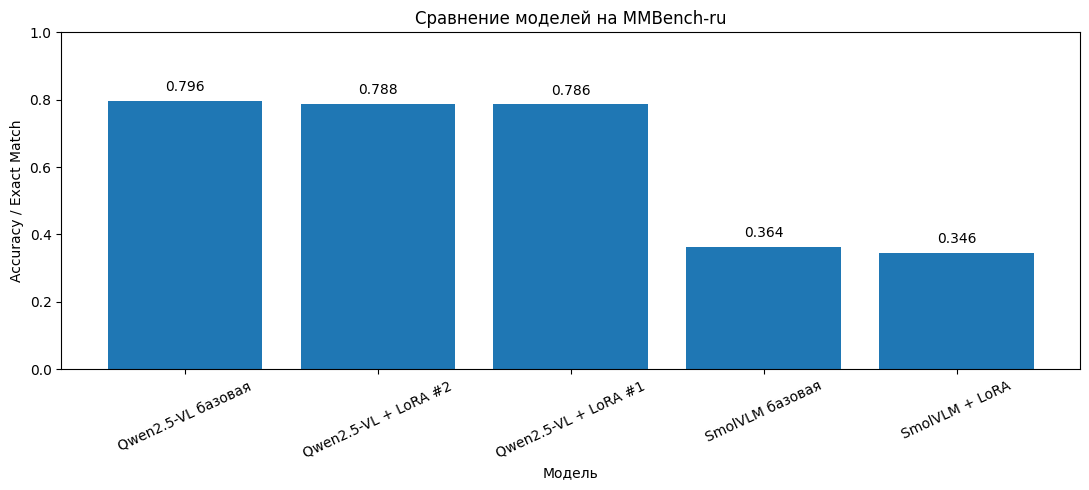

,model_name,status,main_metric,main_score,accuracy,exact_match,num_success,num_errors,mean_inference_time_s
0,Qwen2.5-VL базовая,ok,accuracy,0.796,0.796,NaN,500,0,0.255246
1,SmolVLM базовая,ok,accuracy,0.364,0.364,NaN,500,0,0.290338
2,Qwen2.5-VL + LoRA #1,ok,accuracy,0.786,0.786,NaN,500,0,0.338744
3,Qwen2.5-VL + LoRA #2,ok,accuracy,0.788,0.788,NaN,500,0,0.338611
4,SmolVLM + LoRA,ok,accuracy,0.346,0.346,NaN,500,0,0.347040


In [13]:
plot_df = metrics_df[(metrics_df["status"] == "ok") & metrics_df["main_score"].notna()].copy()

if plot_df.empty:
    show_markdown("Нет успешных метрик для построения графика.")
else:
    plot_df = plot_df.sort_values("main_score", ascending=False)
    fig, ax = plt.subplots(figsize=(11, 5))
    bars = ax.bar(plot_df["model_name"], plot_df["main_score"])
    ax.set_title("Сравнение моделей на MMBench-ru")
    ax.set_xlabel("Модель")
    ax.set_ylabel("Accuracy / Exact Match")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=25)
    for bar, value in zip(bars, plot_df["main_score"]):
        ax.text(bar.get_x() + bar.get_width() / 2, min(value + 0.02, 0.98), f"{value:.3f}", ha="center", va="bottom")
    plt.tight_layout()
    plt.show()

show_df(metrics_df[[
    "model_name",
    "status",
    "main_metric",
    "main_score",
    "accuracy",
    "exact_match",
    "num_success",
    "num_errors",
    "mean_inference_time_s",
]], max_rows=None)

## 14. Примеры ошибок модели

Ниже собраны вопросы, где модель дала неверный ответ. Для multiple-choice в `prediction_norm` хранится извлеченная буква, а в `prediction` — сырой текст модели.

In [14]:
if predictions_df.empty:
    error_examples_df = pd.DataFrame()
    show_markdown("Предсказаний нет, поэтому таблица ошибок пуста.")
else:
    error_examples_df = predictions_df[
        predictions_df["error"].isna() & (~predictions_df["is_correct"].astype(bool))
    ].copy()
    error_examples_view = error_examples_df[[
        "model_name",
        "question",
        "options",
        "true_answer",
        "prediction",
        "prediction_norm",
        "is_correct",
    ]].head(30)
    show_df(error_examples_view, max_rows=30)

if not predictions_df.empty:
    error_count_df = (
        predictions_df[predictions_df["error"].isna()]
        .assign(status=lambda df: np.where(df["is_correct"], "верно", "ошибка"))
        .groupby(["model_name", "status"], as_index=False)
        .size()
        .rename(columns={"size": "Количество примеров", "model_name": "Модель", "status": "Статус"})
    )
    show_df(error_count_df, max_rows=None)

,model_name,question,options,true_answer,prediction,prediction_norm,is_correct
0,Qwen2.5-VL базовая,Какое изображение более яркое?,A. Первое изображение\nB. Второе изображение,B,A,A,False
1,Qwen2.5-VL базовая,Является ли следующее утверждение о нашей солнечной системе правдой или ложью?\nОбъем Марса более чем в три раза больше объема Меркурия.,A. Правда\nB. Ложь,B,A,A,False
2,Qwen2.5-VL базовая,Подумайте о магнитной силе между магнитами в каждой паре. Какое из следующих утверждений является правильным?,A. Величина магнитной силы меньше в Паре 2.\nB. Величина магнитной силы меньше в Паре 1.\nC. Величина магнитной силы одинакова в обеих парах.,B,A,A,False
3,Qwen2.5-VL базовая,Какой термин соответствует картинке?,A. теплопроводность\nB. конвекция,B,A,A,False
4,Qwen2.5-VL базовая,Каковы природные взаимоотношения этих животных?,A. хищничество\nB. мутуализм\nC. паразитизм,C,A,A,False
5,Qwen2.5-VL базовая,Что произойдет дальше?,"A. щенок укусит мужчину\nB. щенок оближет мужчину\nC. щенок сядет на мужчину\nD. и A, и B, и C",A,D,D,False
6,Qwen2.5-VL базовая,Что произойдет дальше?,"A. мужчина пойдет назад\nB. мужчина упадет\nC. мужчина встанет\nD. и A, и B, и C",B,D,D,False
7,Qwen2.5-VL базовая,"Исходя из изображения, какова может быть цель металлической конструкции, построенной вокруг двухэтажного автобуса?",A. Металлическая конструкция обеспечивает укрытие и защиту от непогоды.\nB. Металлическая конструкция используется как уникальное место для проведения мероп...,A,B,B,False
8,Qwen2.5-VL базовая,Какой город является столицей Северной Каролины?,A. Батон-Руж\nB. Шарлотт\nC. Нэшвилл\nD. Роли,D,B,B,False
9,Qwen2.5-VL базовая,Какая из следующих эмоций изображена на этом изображении?,A. иллюзорный\nB. одинокий\nC. счастливый\nD. поддерживающий,A,B,B,False


,Модель,Статус,Количество примеров
0,Qwen2.5-VL + LoRA #1,верно,393
1,Qwen2.5-VL + LoRA #1,ошибка,107
2,Qwen2.5-VL + LoRA #2,верно,394
3,Qwen2.5-VL + LoRA #2,ошибка,106
4,Qwen2.5-VL базовая,верно,398
5,Qwen2.5-VL базовая,ошибка,102
6,SmolVLM + LoRA,верно,173
7,SmolVLM + LoRA,ошибка,327
8,SmolVLM базовая,верно,182
9,SmolVLM базовая,ошибка,318


## 15. Разбор по категориям

Категории помогают быстро увидеть, где модель чаще ошибается. Этот блок готовит таблицу, но не делает финальные выводы за исследователя.

In [15]:
if predictions_df.empty or "category" not in predictions_df.columns:
    show_markdown("Нет данных для разбора по категориям.")
else:
    category_metrics_df = (
        predictions_df[predictions_df["error"].isna()]
        .groupby(["model_name", "category"], as_index=False)
        .agg(
            score=("is_correct", "mean"),
            examples=("is_correct", "size"),
            correct=("is_correct", "sum"),
        )
        .sort_values(["model_name", "score"], ascending=[True, True])
    )
    show_df(category_metrics_df, max_rows=30)

,model_name,category,score,examples,correct
0,Qwen2.5-VL + LoRA #1,object_localization,0.395349,43,17
1,Qwen2.5-VL + LoRA #1,spatial_relationship,0.400000,20,8
2,Qwen2.5-VL + LoRA #1,image_quality,0.448276,29,13
3,Qwen2.5-VL + LoRA #1,physical_relation,0.500000,10,5
4,Qwen2.5-VL + LoRA #1,physical_property_reasoning,0.578947,19,11
5,Qwen2.5-VL + LoRA #1,future_prediction,0.600000,15,9
6,Qwen2.5-VL + LoRA #1,nature_relation,0.687500,16,11
7,Qwen2.5-VL + LoRA #1,ocr,0.722222,18,13
8,Qwen2.5-VL + LoRA #1,structuralized_imagetext_understanding,0.722222,18,13
9,Qwen2.5-VL + LoRA #1,attribute_comparison,0.800000,5,4


# Выводы

- Лучшая модель по основной метрике: ...
- Сравнение базовых моделей: ...
- Эффект LoRA-адаптеров: ...
- Типичные ошибки на MMBench-ru: ...
- Что стоит проверить следующим запуском: ...